In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

In [2]:
arquivo = files.upload()

Saving 069b5e76419f174d1e599b006a69b68d.jpg to 069b5e76419f174d1e599b006a69b68d.jpg


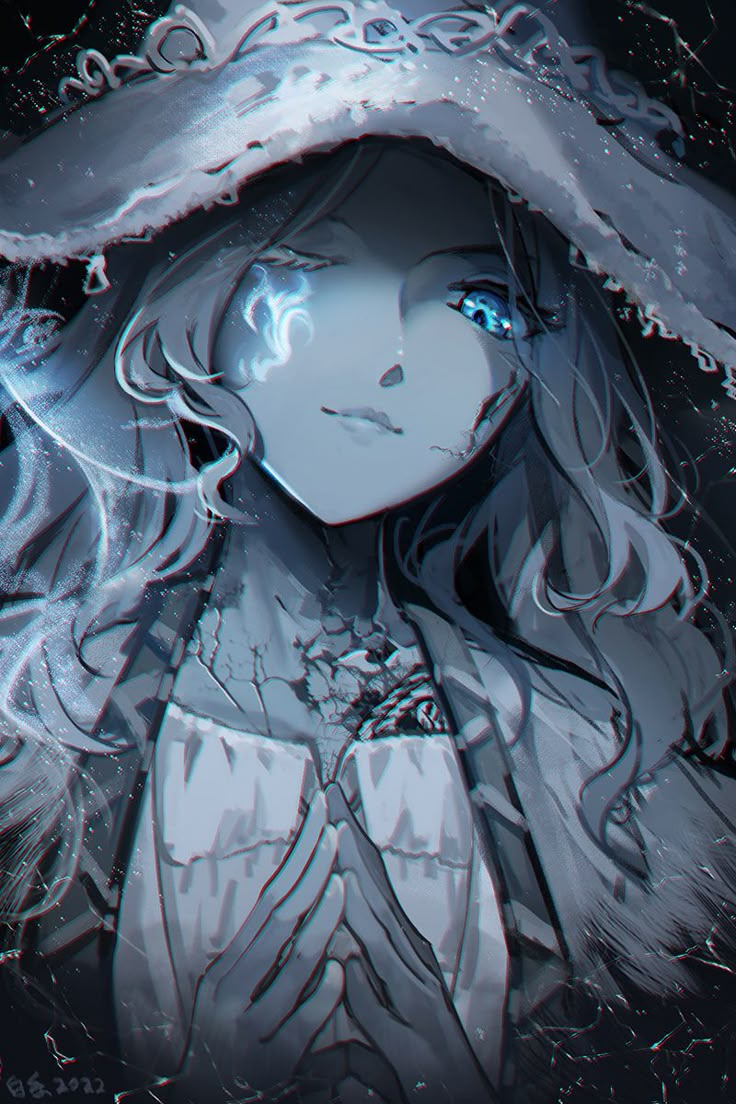

In [3]:
img = cv2.imread('/content/069b5e76419f174d1e599b006a69b68d.jpg')
cv2_imshow(img)

In [4]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

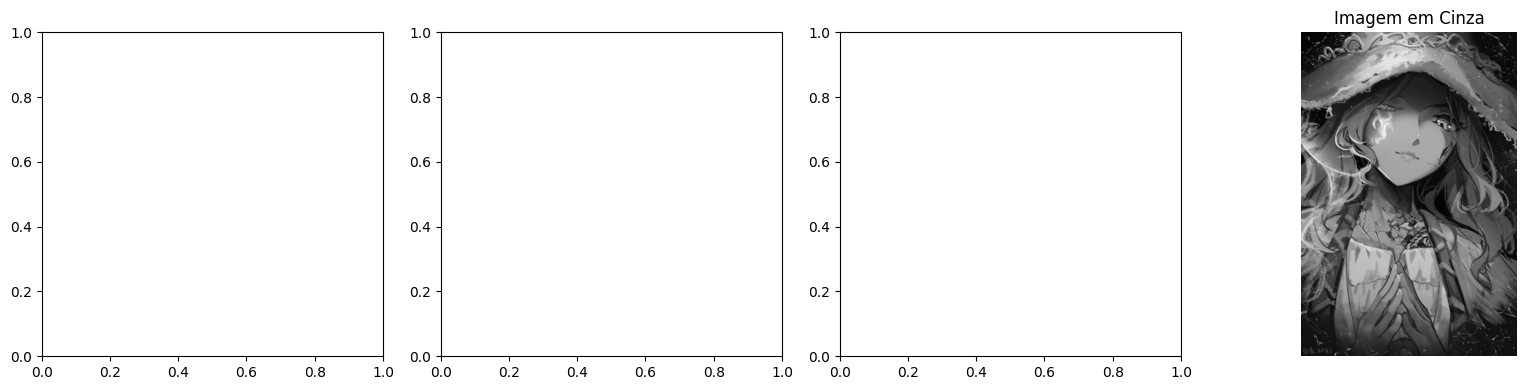

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(16,4))
ax[3].imshow(img_gray, cmap=('gray'))
ax[3].set_title("Imagem em Cinza")
ax[3].axis("off")
plt.tight_layout()
#plt.savefig("conversao_de_cores")
plt.show()

In [7]:
print(img_gray.dtype, img_gray.shape)

uint8 (1104, 736)


In [9]:
def quantizar(img, n_bits):
    """
    Reduz uma imagem em tons de cinza para 2**n_bits níveis de intensidade,
    truncando os bits menos significativos.

    Parameters
    ----------
    img : np.ndarray
        Imagem em tons de cinza, dtype uint8 (valores de 0 a 255).
    n_bits : int
        Número de bits desejado para representar cada pixel (1 a 8).

    Returns
    -------
    np.ndarray
        Imagem quantizada, mesmo shape e dtype, com 2**n_bits níveis distintos.
    """
    deslocamento = 8 - n_bits
    return (img >> deslocamento) << deslocamento

## 1 bit = 7 bits utilizados (apenas os mais importantes)

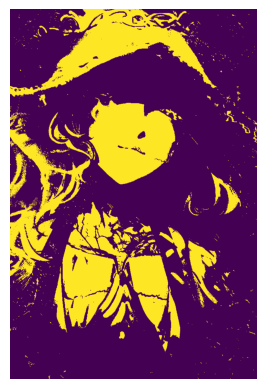

In [10]:
img_1bit = quantizar(img_gray, 1)
plt.imshow(img_1bit)
plt.axis('off')
plt.show()

## 2 bits = 6 bits utilizados (apenas os mais importantes)

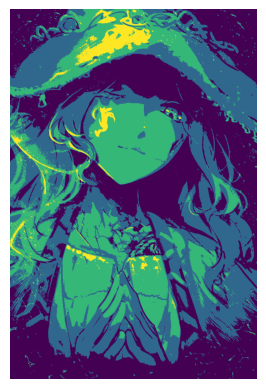

In [11]:
img_2bit = quantizar(img_gray, 2)
plt.imshow(img_2bit)
plt.axis('off')
plt.show()

## 4 bits = 4 bits utilizados (apenas os mais importantes)

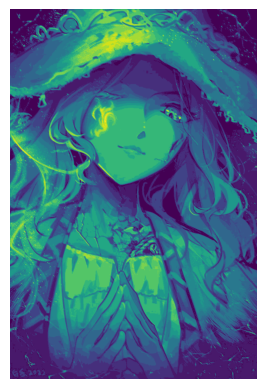

In [12]:
img_4bit = quantizar(img_gray, 4)
plt.imshow(img_4bit)
plt.axis('off')
plt.show()

## 8 bits = 0 bits utilizados (apenas os mais importantes)

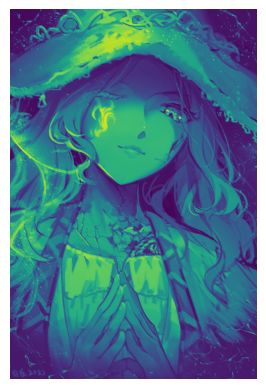

In [13]:
img_8bit = quantizar(img_gray, 8)
plt.imshow(img_8bit)
plt.axis('off')
plt.show()

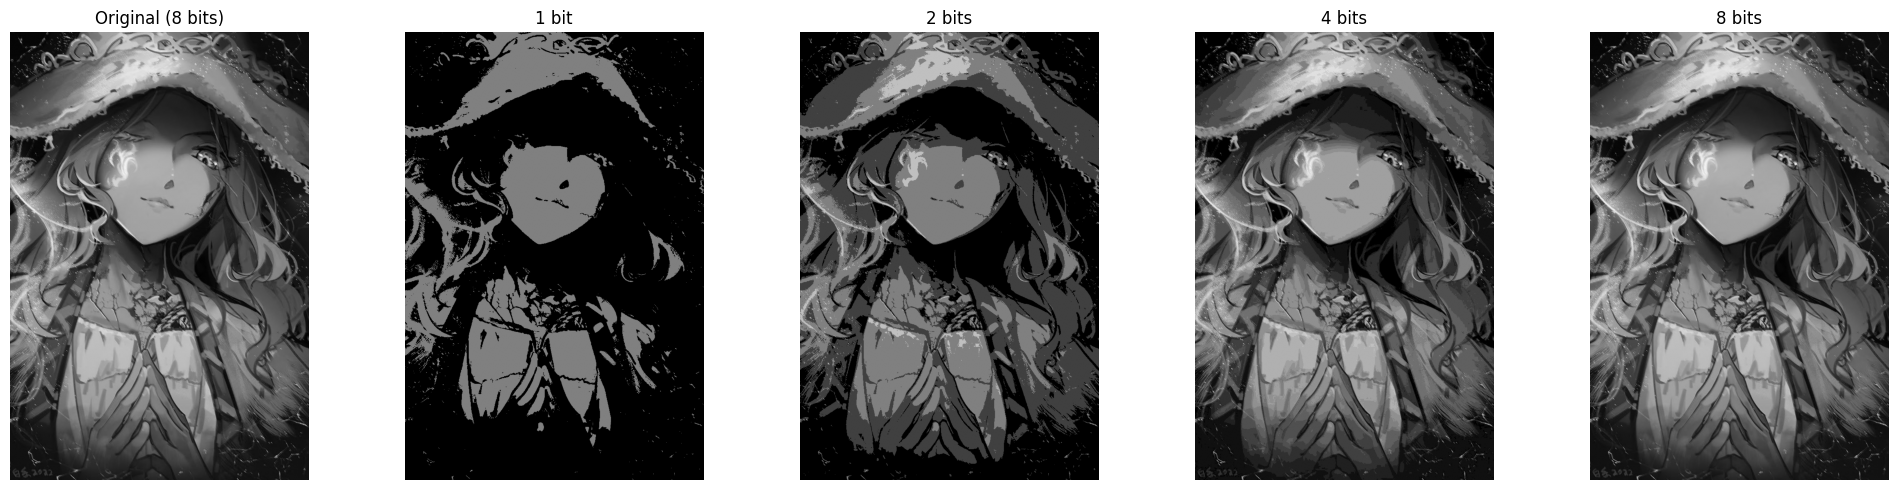

In [16]:
resultados = [
    (img_gray, "Original (8 bits)"),
    (quantizar(img_gray, 1), "1 bit"),
    (quantizar(img_gray, 2), "2 bits"),
    (quantizar(img_gray, 4), "4 bits"),
    (quantizar(img_gray, 8), "8 bits"),
]

fig, eixos = plt.subplots(1, 5, figsize=(20, 5))

for eixo, (imagem, titulo) in zip(eixos, resultados):
    eixo.imshow(imagem, cmap='gray', vmin=0, vmax=255)
    eixo.set_title(titulo)
    eixo.axis('off')

plt.tight_layout()
plt.savefig('quantizacao.png', dpi=300, bbox_inches='tight')
plt.show()

# Sobre o efeito visual percebido:

Conforme reduzimos o número de bits, as diferenças entre as imagem se tornam mais perceptíveis. Isso acontece por conta que a perda de informação é maior quando o nível de intensidade é baixo.

<Figure size 640x480 with 0 Axes>